# Benchmark HLoc 6-DoF error

This notebook is independent of the expensive AnyLoc and HLoc inference cells. It reads the saved HLoc poses and ARKit manifests, computes translation/rotation errors, and writes an Excel workbook with per-frame and summary metrics.

## Coordinate-frame warning

Separate ARKit recordings normally have independent world origins. The workbook therefore reports:

- `raw`: direct comparison, valid only if ARKit reused the same world frame;
- `first_pose_aligned`: maps the first query camera pose onto the first reference pose, which assumes both recordings began at the same physical pose.

For a publication-quality benchmark, replace this assumption with an independently measured cross-session transform.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src' / 'indoor_vpr').is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Could not find the indoor-VPR project root.')
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr.localization import export_hloc_benchmark_xlsx

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'localization'
RESULTS_PATH = OUTPUT_DIR / 'hloc' / 'hloc_poses.txt'
REFERENCE_MANIFEST = OUTPUT_DIR / 'images' / 'reference_manifest.csv'
QUERY_MANIFEST = OUTPUT_DIR / 'images' / 'query_manifest.csv'
BENCHMARK_XLSX = OUTPUT_DIR / 'hloc_benchmark.xlsx'

# Adjustable localization-recall thresholds: (translation meters, rotation degrees)
THRESHOLDS = ((0.25, 2.0), (0.5, 5.0), (1.0, 10.0))
for required in (RESULTS_PATH, REFERENCE_MANIFEST, QUERY_MANIFEST):
    if not required.is_file():
        raise FileNotFoundError(required)


## Compute and export errors

In [2]:
workbook_path, benchmark = export_hloc_benchmark_xlsx(
    RESULTS_PATH,
    REFERENCE_MANIFEST,
    QUERY_MANIFEST,
    BENCHMARK_XLSX,
    thresholds=THRESHOLDS,
)
for alignment_mode, result in benchmark.items():
    print(f'\n{alignment_mode}')
    for metric, value in result['summary'].items():
        if isinstance(value, float):
            print(f'  {metric:28s}: {value:.4f}')
        else:
            print(f'  {metric:28s}: {value}')
print('\nWorkbook:', workbook_path)



raw
  query_count                 : 155
  pnp_success_count           : 155
  pnp_success_rate            : 1.0000
  median_translation_m        : 0.0610
  mean_translation_m          : 0.7054
  p90_translation_m           : 0.3198
  median_rotation_deg         : 0.9179
  mean_rotation_deg           : 6.9014
  p90_rotation_deg            : 6.0195
  recall_0.25m_2deg           : 0.7677
  recall_0.5m_5deg            : 0.8903
  recall_1m_10deg             : 0.9032

first_pose_aligned
  query_count                 : 155
  pnp_success_count           : 155
  pnp_success_rate            : 1.0000
  median_translation_m        : 0.4107
  mean_translation_m          : 1.0314
  p90_translation_m           : 0.7658
  median_rotation_deg         : 6.5295
  mean_rotation_deg           : 11.8283
  p90_rotation_deg            : 9.5775
  recall_0.25m_2deg           : 0.0000
  recall_0.5m_5deg            : 0.0129
  recall_1m_10deg             : 0.8968

Workbook: /Users/armin/Documents/indoor-VPR/outpu

## Visualize localization quality

This section reads saved poses and manifests only. `raw` is appropriate when the two ARKit recordings already share a map; select `first_pose_aligned` when using the documented common-start assumption.

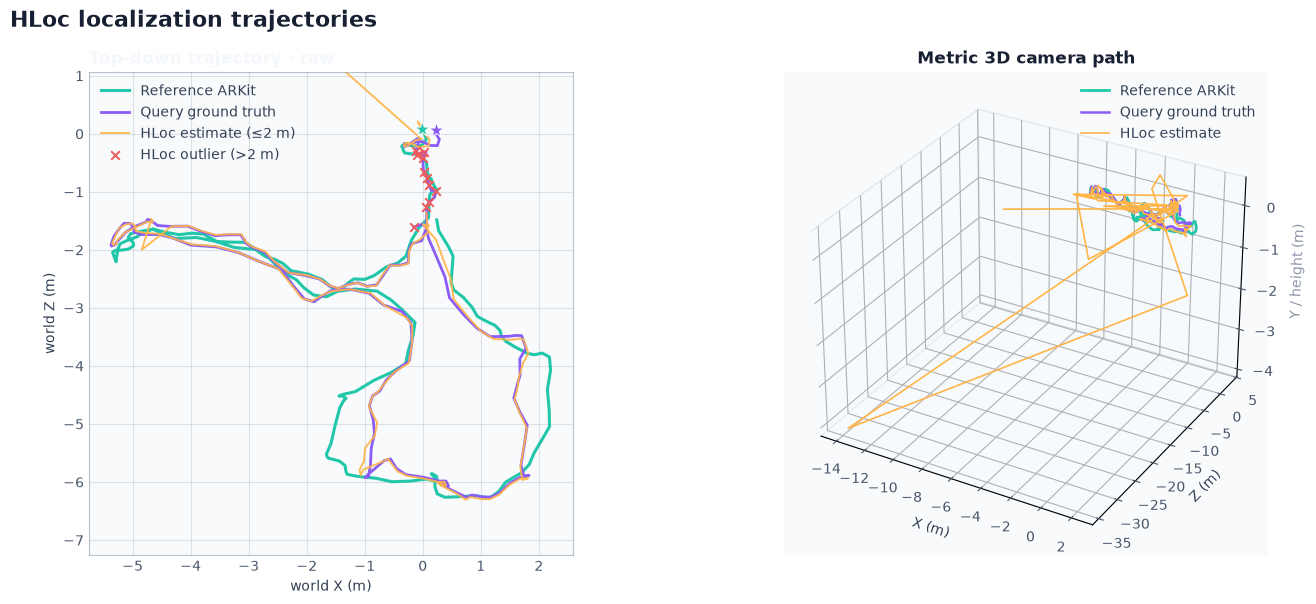

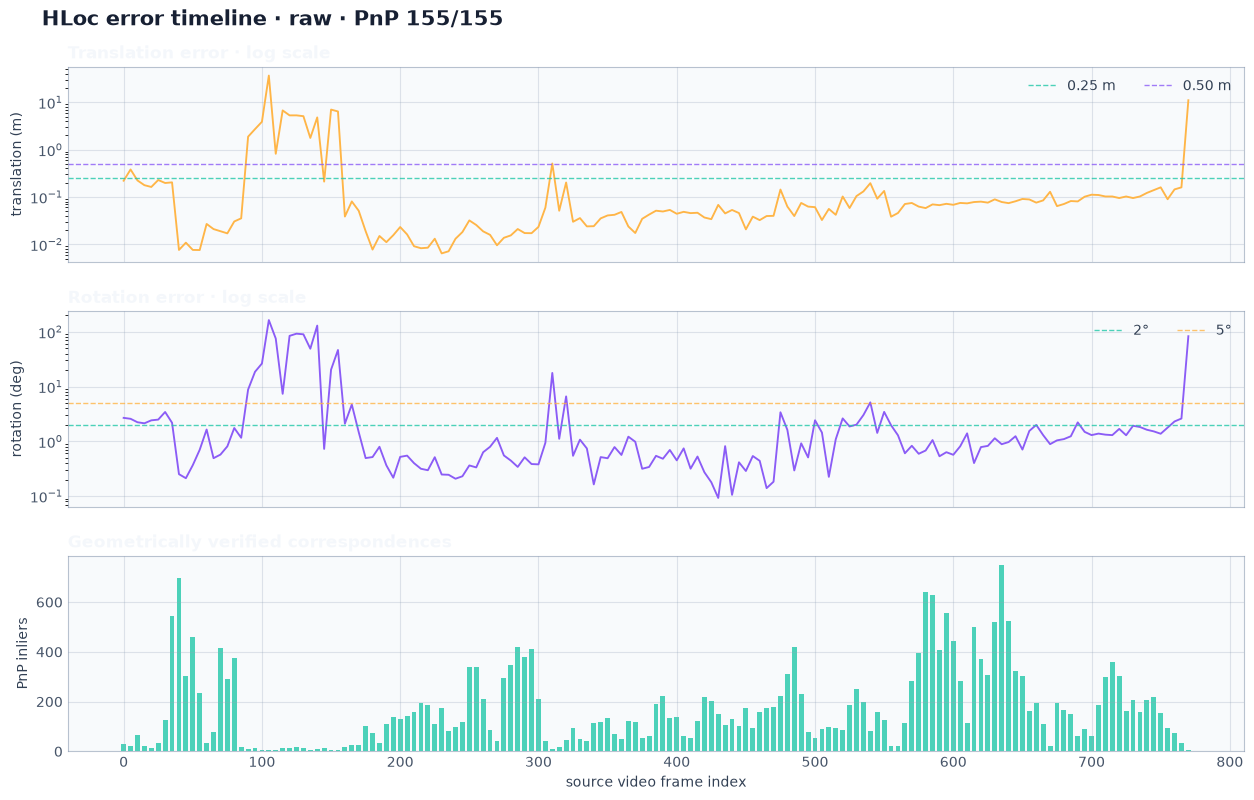

Trajectory: /Users/armin/Documents/indoor-VPR/outputs/localization/hloc_trajectories_raw.png
Errors:     /Users/armin/Documents/indoor-VPR/outputs/localization/hloc_error_timeline_raw.png


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src' / 'indoor_vpr').is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Could not find the indoor-VPR project root.')
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
from IPython.display import display
from indoor_vpr.localization import plot_hloc_error_timeline, plot_hloc_trajectories

def apply_light_theme(figure):
    """Restyle the saved HLoc figures for a white thesis page."""
    figure.set_facecolor('white')
    if figure._suptitle is not None:
        figure._suptitle.set_color('#172033')
    for axis in figure.axes:
        axis.set_facecolor('#f8fafc')
        axis.tick_params(colors='#475569')
        axis.xaxis.label.set_color('#334155')
        axis.yaxis.label.set_color('#334155')
        axis.title.set_color('#172033')
        axis.grid(color='#94a3b8', alpha=.28)
        for spine in axis.spines.values():
            spine.set_color('#94a3b8')
            spine.set_alpha(.65)
        legend = axis.get_legend()
        if legend is not None:
            for text in legend.get_texts():
                text.set_color('#334155')
        # Matplotlib's 3D axes use pane faces independently of set_facecolor.
        for name in ('xaxis', 'yaxis', 'zaxis'):
            three_d_axis = getattr(axis, name, None)
            if three_d_axis is not None and hasattr(three_d_axis, 'pane'):
                three_d_axis.pane.set_facecolor((.97, .98, 1, 1))
                three_d_axis.pane.set_edgecolor('#cbd5e1')

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'localization'
RESULTS_PATH = OUTPUT_DIR / 'hloc' / 'hloc_poses.txt'
REFERENCE_MANIFEST = OUTPUT_DIR / 'images' / 'reference_manifest.csv'
QUERY_MANIFEST = OUTPUT_DIR / 'images' / 'query_manifest.csv'
ALIGNMENT_MODE = 'raw'  # 'raw' or 'first_pose_aligned'

trajectory_figure = plot_hloc_trajectories(
    RESULTS_PATH, REFERENCE_MANIFEST, QUERY_MANIFEST,
    alignment_mode=ALIGNMENT_MODE,
)
apply_light_theme(trajectory_figure)
trajectory_path = OUTPUT_DIR / f'hloc_trajectories_{ALIGNMENT_MODE}.png'
trajectory_figure.savefig(trajectory_path, dpi=150, facecolor=trajectory_figure.get_facecolor())
display(trajectory_figure)
plt.close(trajectory_figure)

error_figure = plot_hloc_error_timeline(
    RESULTS_PATH, REFERENCE_MANIFEST, QUERY_MANIFEST,
    alignment_mode=ALIGNMENT_MODE,
)
apply_light_theme(error_figure)
error_path = OUTPUT_DIR / f'hloc_error_timeline_{ALIGNMENT_MODE}.png'
error_figure.savefig(error_path, dpi=150, facecolor=error_figure.get_facecolor())
display(error_figure)
plt.close(error_figure)

print('Trajectory:', trajectory_path)
print('Errors:    ', error_path)
